In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt


In [2]:

from skimage.exposure import match_histograms
from skimage.measure import shannon_entropy


In [3]:
image=cv2.imread("luffy.jpg",cv2.IMREAD_GRAYSCALE)

Images loaded successfully.
Input image shape: (437, 735)
Reference image shape: (1308, 736)


/var/folders/jv/3jcqz5md76gc2vx6rbbd25wr0000gn/T/ipykernel_8699/1419122749.py:156: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(reference_image.ravel(), 256, [0, 256])


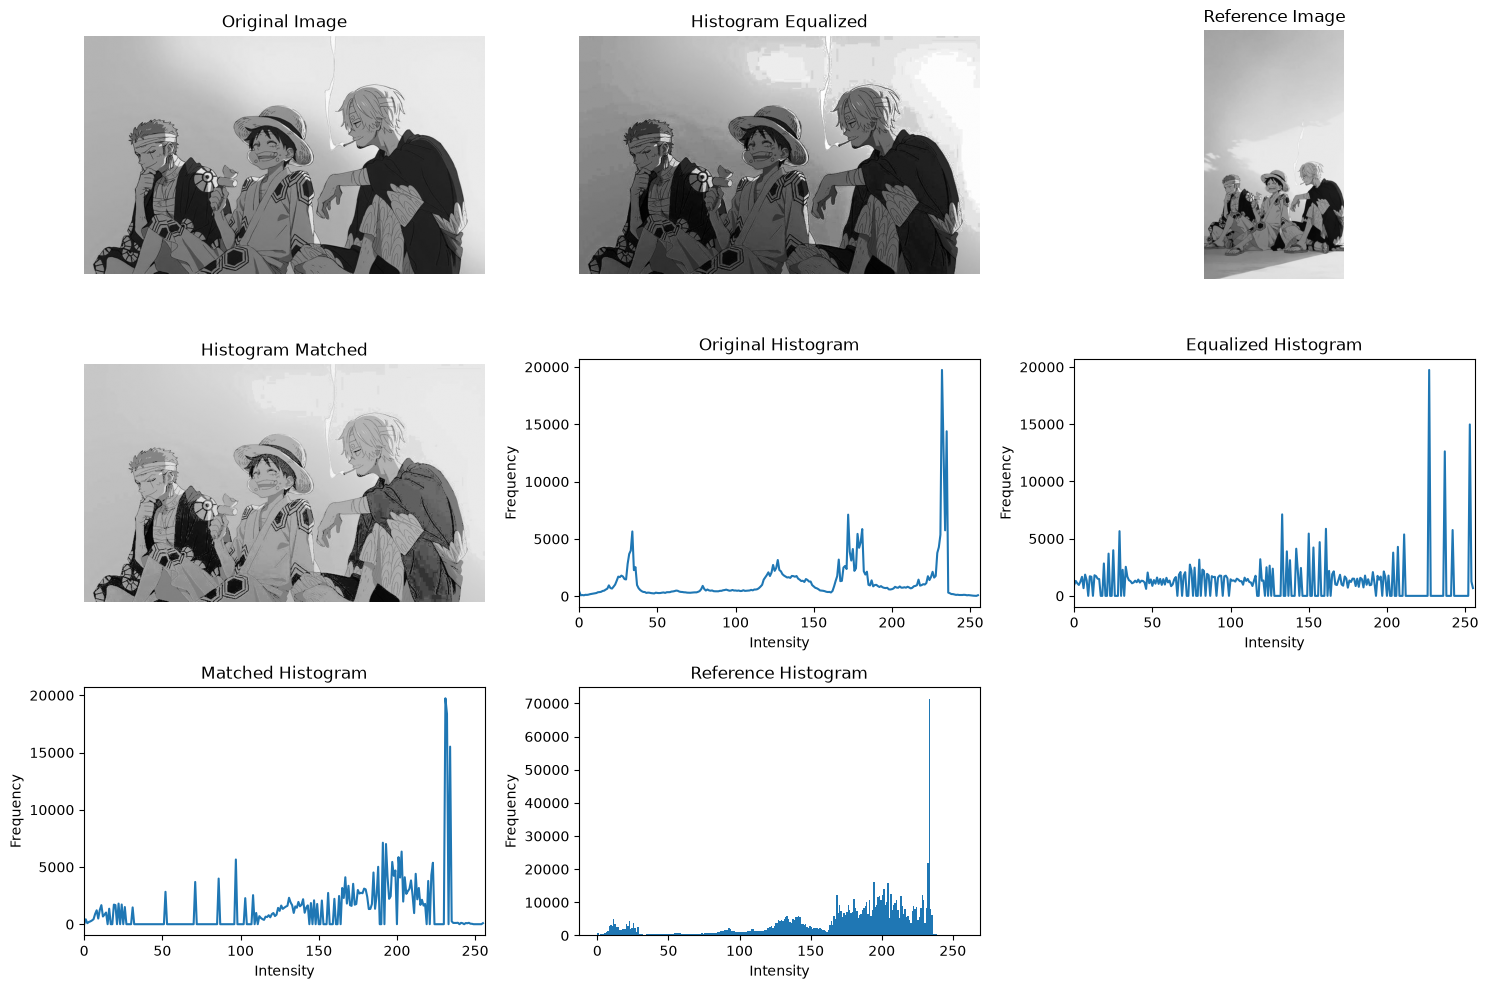


Quantitative Comparison
---------------------------------------------------------------------------
Image                    Mean           Std Dev        Entropy        Contrast       
---------------------------------------------------------------------------
Original                 153.62         68.94          7.12           68.94          
Histogram Equalized      129.08         74.99          6.80           74.99          
Histogram Matched        172.23         58.06          6.44           58.06          
---------------------------------------------------------------------------

Reference Image Measures
--------------------------------------------------
Mean       : 172.13
Std Dev    : 58.53
Entropy    : 7.12
Contrast   : 58.53
--------------------------------------------------


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.exposure import match_histograms
from skimage.measure import shannon_entropy

# Step 1: Read Images

# Read both images directly as grayscale images
input_image = cv2.imread("input.jpeg", cv2.IMREAD_GRAYSCALE)
reference_image = cv2.imread("reference.jpeg", cv2.IMREAD_GRAYSCALE)

# Check whether the images were loaded successfully
if input_image is None:
    print("Error: input.jpeg not found or could not be read.")
    raise FileNotFoundError("input.jpeg not found")

if reference_image is None:
    print("Error: reference.jpeg not found or could not be read.")
    raise FileNotFoundError("reference.jpeg not found")

print("Images loaded successfully.")
print("Input image shape:", input_image.shape)
print("Reference image shape:", reference_image.shape)


# Step 2: Histogram of Original Image

# Calculate histogram of the original grayscale image
original_hist = cv2.calcHist(
    [input_image],
    [0],
    None,
    [256],
    [0, 256]
)


# Step 3: Histogram Equalization

# Equalize the histogram of the input image
equalized_image = cv2.equalizeHist(input_image)

# Calculate histogram of the equalized image
equalized_hist = cv2.calcHist(
    [equalized_image],
    [0],
    None,
    [256],
    [0, 256]
)


# Step 4: Histogram Matching

# Match the histogram of input image with the reference image
matched_image = match_histograms(
    input_image,
    reference_image
)

# Convert the result to 8-bit unsigned integer
matched_image = np.uint8(matched_image)

# Calculate histogram of the matched image
matched_hist = cv2.calcHist(
    [matched_image],
    [0],
    None,
    [256],
    [0, 256]
)


# Step 5: Calculate Quantitative Measures

def calculate_measures(image):
    # Mean represents average brightness
    mean = np.mean(image)

    # Standard deviation represents intensity variation
    standard_deviation = np.std(image)

    # Entropy represents information or intensity diversity
    entropy = shannon_entropy(image)

    # Here contrast is defined using standard deviation
    contrast = standard_deviation

    return mean, standard_deviation, entropy, contrast


# Calculate measures for all three images
original_measures = calculate_measures(input_image)
equalized_measures = calculate_measures(equalized_image)
matched_measures = calculate_measures(matched_image)


# Step 6: Display Images

plt.figure(figsize=(15, 10))

# Original image
plt.subplot(3, 3, 1)
plt.imshow(input_image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

# Histogram equalized image
plt.subplot(3, 3, 2)
plt.imshow(equalized_image, cmap="gray")
plt.title("Histogram Equalized")
plt.axis("off")

# Reference image
plt.subplot(3, 3, 3)
plt.imshow(reference_image, cmap="gray")
plt.title("Reference Image")
plt.axis("off")

# Histogram matched image
plt.subplot(3, 3, 4)
plt.imshow(matched_image, cmap="gray")
plt.title("Histogram Matched")
plt.axis("off")


# Step 7: Display Histograms

# Original histogram
plt.subplot(3, 3, 5)
plt.plot(original_hist)
plt.title("Original Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency")
plt.xlim([0, 256])

# Equalized histogram
plt.subplot(3, 3, 6)
plt.plot(equalized_hist)
plt.title("Equalized Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency")
plt.xlim([0, 256])

# Matched histogram
plt.subplot(3, 3, 7)
plt.plot(matched_hist)
plt.title("Matched Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency")
plt.xlim([0, 256])

# Reference histogram
plt.subplot(3, 3, 8)
plt.hist(reference_image.ravel(), 256, [0, 256])
plt.title("Reference Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


# Step 8: Display Quantitative Results

print("\nQuantitative Comparison")
print("-" * 75)

print(
    f"{'Image':<25}"
    f"{'Mean':<15}"
    f"{'Std Dev':<15}"
    f"{'Entropy':<15}"
    f"{'Contrast':<15}"
)

print("-" * 75)

print(
    f"{'Original':<25}"
    f"{original_measures[0]:<15.2f}"
    f"{original_measures[1]:<15.2f}"
    f"{original_measures[2]:<15.2f}"
    f"{original_measures[3]:<15.2f}"
)

print(
    f"{'Histogram Equalized':<25}"
    f"{equalized_measures[0]:<15.2f}"
    f"{equalized_measures[1]:<15.2f}"
    f"{equalized_measures[2]:<15.2f}"
    f"{equalized_measures[3]:<15.2f}"
)

print(
    f"{'Histogram Matched':<25}"
    f"{matched_measures[0]:<15.2f}"
    f"{matched_measures[1]:<15.2f}"
    f"{matched_measures[2]:<15.2f}"
    f"{matched_measures[3]:<15.2f}"
)

print("-" * 75)


# Step 9: Display Reference Image Measures

reference_measures = calculate_measures(reference_image)

print("\nReference Image Measures")
print("-" * 50)

print(f"Mean       : {reference_measures[0]:.2f}")
print(f"Std Dev    : {reference_measures[1]:.2f}")
print(f"Entropy    : {reference_measures[2]:.2f}")
print(f"Contrast   : {reference_measures[3]:.2f}")

print("-" * 50)